## Gradient Analysis

In [1]:
# setup

import sys
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from data import build_vocab, encode, make_chunks, CharDataset
from rnn import VanillaRNN
from lstm import LSTMModel
from torch.utils.data import DataLoader

device = torch.device("cpu")

# reloading corpus and vocab
PROCESSED_DATA_DIR = Path.cwd().parent / "data" / "processed"
with open(PROCESSED_DATA_DIR / "corpus_clean.txt", "r", encoding="utf-8") as f:
    text = f.read()

train_text = text[:738058]
test_text  = text[897611:]

char2idx, idx2char = build_vocab(train_text, min_count=10)
vocab_size = len(idx2char)

print(f"Vocab size: {vocab_size}")

Vocab size: 71


In [2]:
# loading the best checkpoints

CHECKPOINT_DIR = Path.cwd().parent / "checkpoints"

rnn_model = VanillaRNN(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
rnn_checkpoint = torch.load(CHECKPOINT_DIR / "rnn_best.pt", map_location=device)
rnn_model.load_state_dict(rnn_checkpoint["model_state_dict"])
rnn_model.to(device)
print(f"RNN loaded from epoch {rnn_checkpoint['epoch']+1}, "
      f"val loss: {rnn_checkpoint['val_loss']:.4f}")

lstm_model = LSTMModel(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
lstm_checkpoint = torch.load(CHECKPOINT_DIR / "lstm_best.pt", map_location=device)
lstm_model.load_state_dict(lstm_checkpoint["model_state_dict"])
lstm_model.to(device)
print(f"LSTM loaded from epoch {lstm_checkpoint['epoch']+1}, "
      f"val loss: {lstm_checkpoint['val_loss']:.4f}")

RNN loaded from epoch 20, val loss: 1.4449
LSTM loaded from epoch 20, val loss: 1.4327


In [3]:
# randomly initializing models

rnn_untrained  = VanillaRNN(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
lstm_untrained = LSTMModel(vocab_size=vocab_size,  embed_dim=64, hidden_size=256)

rnn_untrained.to(device)
lstm_untrained.to(device)

print("Untrained RNN and LSTM initialized with random weights.")

Untrained RNN and LSTM initialized with random weights.


In [4]:
# initializing gradient norms

def get_gradient_norms(model, input_seq, target_seq, model_type="rnn"):

    model.train()

    input_seq  = input_seq.unsqueeze(0).to(device)
    target_seq = target_seq.unsqueeze(0).to(device)

    if model_type == "rnn":
        h0 = model.init_hidden(1, device)
        logits, _, hidden_states = model(input_seq, h0, track_gradients=True)
    else:
        h0, c0 = model.init_hidden(1, device)
        logits, _, _, hidden_states = model(input_seq, h0, c0, track_gradients=True)

    criterion = torch.nn.CrossEntropyLoss()
    loss = criterion(
        logits.view(-1, logits.size(-1)),
        target_seq.view(-1)
    )

    loss.backward()

    norms = []
    for h_t in hidden_states:
        if h_t.grad is not None:

            norms.append(h_t.grad.norm().item())
        else:
            norms.append(0.0)

    return norms

In [5]:
# average gradient norms over 50 test sequences

N_SEQUENCES = 50
SEQ_LEN     = 100

test_encoded = encode(test_text, char2idx)
test_chunks  = make_chunks(test_encoded, seq_len=SEQ_LEN)

# per-sequence gradient norms for both models
rnn_all_norms  = []
lstm_all_norms = []

for i in range(N_SEQUENCES):
    input_seq, target_seq = test_chunks[i]
    input_tensor  = torch.tensor(input_seq,  dtype=torch.long)
    target_tensor = torch.tensor(target_seq, dtype=torch.long)

    # RNN gradient norms for this sequence
    rnn_norms = get_gradient_norms(rnn_model, input_tensor, target_tensor,
                                   model_type="rnn")
    rnn_all_norms.append(rnn_norms)

    # LSTM gradient norms for this sequence
    lstm_norms = get_gradient_norms(lstm_model, input_tensor, target_tensor,
                                    model_type="lstm")
    lstm_all_norms.append(lstm_norms)

rnn_norms_array  = np.array(rnn_all_norms)
lstm_norms_array = np.array(lstm_all_norms)

rnn_mean  = rnn_norms_array.mean(axis=0)
rnn_std   = rnn_norms_array.std(axis=0)
lstm_mean = lstm_norms_array.mean(axis=0)
lstm_std  = lstm_norms_array.std(axis=0)

print(f"RNN  — mean norm at t=0 (earliest): {rnn_mean[0]:.6f}")
print(f"RNN  — mean norm at t=99 (latest):  {rnn_mean[-1]:.6f}")
print(f"LSTM — mean norm at t=0 (earliest): {lstm_mean[0]:.6f}")
print(f"LSTM — mean norm at t=99 (latest):  {lstm_mean[-1]:.6f}")

RNN  — mean norm at t=0 (earliest): 0.044301
RNN  — mean norm at t=99 (latest):  0.015234
LSTM — mean norm at t=0 (earliest): 0.041408
LSTM — mean norm at t=99 (latest):  0.018727


In [6]:
# average gradient norm over 50 test sequences on untrained models

rnn_untrained_all_norms  = []
lstm_untrained_all_norms = []

for i in range(N_SEQUENCES):
    input_seq, target_seq = test_chunks[i]
    input_tensor  = torch.tensor(input_seq,  dtype=torch.long)
    target_tensor = torch.tensor(target_seq, dtype=torch.long)

    rnn_norms  = get_gradient_norms(rnn_untrained,  input_tensor, target_tensor,
                                    model_type="rnn")
    lstm_norms = get_gradient_norms(lstm_untrained, input_tensor, target_tensor,
                                    model_type="lstm")

    rnn_untrained_all_norms.append(rnn_norms)
    lstm_untrained_all_norms.append(lstm_norms)

rnn_u_array  = np.array(rnn_untrained_all_norms)
lstm_u_array = np.array(lstm_untrained_all_norms)

rnn_u_mean  = rnn_u_array.mean(axis=0)
rnn_u_std   = rnn_u_array.std(axis=0)
lstm_u_mean = lstm_u_array.mean(axis=0)
lstm_u_std  = lstm_u_array.std(axis=0)

print(f"Untrained RNN  — mean norm at t=0:  {rnn_u_mean[0]:.6f}")
print(f"Untrained RNN  — mean norm at t=99: {rnn_u_mean[-1]:.6f}")
print(f"Untrained LSTM — mean norm at t=0:  {lstm_u_mean[0]:.6f}")
print(f"Untrained LSTM — mean norm at t=99: {lstm_u_mean[-1]:.6f}")

Untrained RNN  — mean norm at t=0:  0.006558
Untrained RNN  — mean norm at t=99: 0.005774
Untrained LSTM — mean norm at t=0:  0.005802
Untrained LSTM — mean norm at t=99: 0.005724


In [7]:
# reinitializing W_hh with small weights

import torch.nn as nn

rnn_forced = VanillaRNN(vocab_size=vocab_size, embed_dim=64, hidden_size=256)
lstm_forced = LSTMModel(vocab_size=vocab_size, embed_dim=64, hidden_size=256)

with torch.no_grad():
    rnn_forced.W_hh.weight.mul_(0.1)

rnn_forced.to(device)
lstm_forced.to(device)

# re-running gradient norm analysis
rnn_forced_norms  = []
lstm_forced_norms = []

for i in range(N_SEQUENCES):
    input_seq, target_seq = test_chunks[i]
    input_tensor  = torch.tensor(input_seq,  dtype=torch.long)
    target_tensor = torch.tensor(target_seq, dtype=torch.long)

    rnn_forced_norms.append(
        get_gradient_norms(rnn_forced, input_tensor, target_tensor, model_type="rnn"))
    lstm_forced_norms.append(
        get_gradient_norms(lstm_forced, input_tensor, target_tensor, model_type="lstm"))

rnn_f_array  = np.array(rnn_forced_norms)
lstm_f_array = np.array(lstm_forced_norms)

rnn_f_mean  = rnn_f_array.mean(axis=0)
lstm_f_mean = lstm_f_array.mean(axis=0)

print(f"Forced RNN  — mean norm at t=0:  {rnn_f_mean[0]:.8f}")
print(f"Forced RNN  — mean norm at t=99: {rnn_f_mean[-1]:.8f}")
print(f"Forced LSTM — mean norm at t=0:  {lstm_f_mean[0]:.8f}")
print(f"Forced LSTM — mean norm at t=99: {lstm_f_mean[-1]:.8f}")
print(f"\nRNN  decay ratio (t=0 / t=99): {rnn_f_mean[0] / (rnn_f_mean[-1] + 1e-10):.4f}")
print(f"LSTM decay ratio (t=0 / t=99): {lstm_f_mean[0] / (lstm_f_mean[-1] + 1e-10):.4f}")

Forced RNN  — mean norm at t=0:  0.00571994
Forced RNN  — mean norm at t=99: 0.00570561
Forced LSTM — mean norm at t=0:  0.00578959
Forced LSTM — mean norm at t=99: 0.00572643

RNN  decay ratio (t=0 / t=99): 1.0025
LSTM decay ratio (t=0 / t=99): 1.0110


In [8]:
# gradient analysis summary
print("H1 Gradient Analysis — Summary")
print("=" * 50)
print(f"Trained  RNN  decay ratio (t=0/t=99): "
      f"{rnn_mean[0]/(rnn_mean[-1]+1e-10):.4f}")
print(f"Trained  LSTM decay ratio (t=0/t=99): "
      f"{lstm_mean[0]/(lstm_mean[-1]+1e-10):.4f}")
print(f"Untrained RNN  decay ratio:            "
      f"{rnn_u_mean[0]/(rnn_u_mean[-1]+1e-10):.4f}")
print(f"Forced   RNN  decay ratio:             "
      f"{rnn_f_mean[0]/(rnn_f_mean[-1]+1e-10):.4f}")
print()
print("Finding: no clear vanishing gradient signal in norm-based analysis.")
print("Reason:  high-dimensional hidden state, Kaiming init, weight adaptation.")
print("Evidence for H1 redirected to loss curve crossover (notebook 02).")
print("H3 distance-vs-loss analysis (notebook 04) provides quantitative support.")

H1 Gradient Analysis — Summary
Trained  RNN  decay ratio (t=0/t=99): 2.9081
Trained  LSTM decay ratio (t=0/t=99): 2.2112
Untrained RNN  decay ratio:            1.1357
Forced   RNN  decay ratio:             1.0025

Finding: no clear vanishing gradient signal in norm-based analysis.
Reason:  high-dimensional hidden state, Kaiming init, weight adaptation.
Evidence for H1 redirected to loss curve crossover (notebook 02).
H3 distance-vs-loss analysis (notebook 04) provides quantitative support.


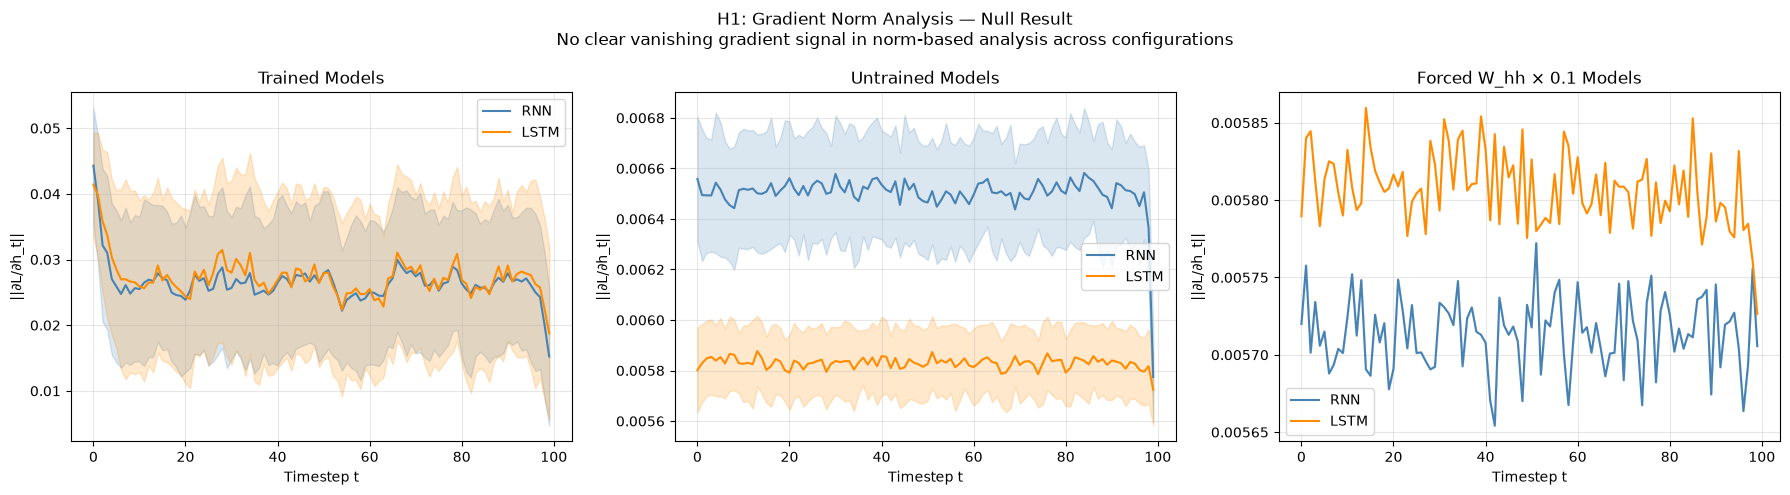

Saved to results/figures/gradient_norms_null_result.png


In [9]:
# plotting the gradient analysis results
timesteps = np.arange(SEQ_LEN)
FIGURES_DIR = Path.cwd().parent / "results" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    (rnn_mean,   lstm_mean,   rnn_std,   lstm_std,   "Trained"),
    (rnn_u_mean, lstm_u_mean, rnn_u_std, lstm_u_std, "Untrained"),
    (rnn_f_mean, lstm_f_mean,
     np.zeros_like(rnn_f_mean), np.zeros_like(lstm_f_mean), "Forced W_hh × 0.1"),
]

for ax, (rnn_m, lstm_m, rnn_s, lstm_s, title) in zip(axes, configs):
    ax.plot(timesteps, rnn_m,  color="steelblue",  label="RNN")
    ax.plot(timesteps, lstm_m, color="darkorange", label="LSTM")
    ax.fill_between(timesteps, rnn_m  - rnn_s,  rnn_m  + rnn_s,
                    alpha=0.2, color="steelblue")
    ax.fill_between(timesteps, lstm_m - lstm_s, lstm_m + lstm_s,
                    alpha=0.2, color="darkorange")
    ax.set_title(f"{title} Models")
    ax.set_xlabel("Timestep t")
    ax.set_ylabel("||∂L/∂h_t||")
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(
    "H1: Gradient Norm Analysis — Null Result\n"
    "No clear vanishing gradient signal in norm-based analysis across configurations",
    fontsize=12
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gradient_norms_null_result.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Saved to results/figures/gradient_norms_null_result.png")